<a href="https://colab.research.google.com/github/Deangr-econ/Quant_methods_project/blob/main/VAR_GPRD_OIL_GAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
import statsmodels.api as sm
import scipy.stats as stats
from fredapi import Fred
from google.colab import userdata

In [5]:
# 1. Data Loading
gpr = pd.read_stata("/content/drive/Othercomputers/My Laptop/Documents/Maastricht University/Master/Quantitative Techniques for Financial Economics/data_gpr_daily_recent.dta")
gpr['date'] = pd.to_datetime(gpr['date'])
gpr = gpr.set_index('date')

fred = Fred(api_key=userdata.get('fredapi_key'))
oil_data = fred.get_series('DCOILBRENTEU', observation_start='1985-01-01')
gas_data = fred.get_series('DHHNGSP', observation_start='1985-01-01')
crude_volatility = fred.get_series('OVXCLS', observation_start='1985-01-01')
ten_y_exp_inflation = fred.get_series('T10YIE', observation_start='1985-01-01')
treasury_2y = fred.get_series('DGS2', observation_start='1985-01-01')

fred_data = pd.DataFrame({
    'OIL_PRICE': oil_data,
    'GAS_PRICE': gas_data,
    'CRUDE_VOLATILITY': crude_volatility,
    'EXP_INFLATION': ten_y_exp_inflation,
    'INTEREST_RATE': treasury_2y
    })
fred_data['INTEREST_RATE'] = pd.to_numeric(fred_data['INTEREST_RATE'], errors='coerce')

In [6]:
#2. Data transformation


# # Download Energy Futures
# fred_data = yf.download(
#     tickers=['CL=F', 'NG=F'],
#     start='1990-01-01',
#     auto_adjust=True
# )['Close']

# Strip timezone if present
fred_data.index = pd.to_datetime(fred_data.index).tz_localize(None)
gpr.index = pd.to_datetime(gpr.index).tz_localize(None)

merged = fred_data.join(gpr['GPRD'], how='inner')
# 2. Find the first timestamp where ALL columns have non-null values
first_valid = merged.dropna().index.min()
# 3. Slice from that date onward
data = merged.loc[first_valid:].dropna()

# 4. Clean non-positive crude anomaly (2020-04-20)
data['OIL_PRICE'] = data['OIL_PRICE'].mask(data['OIL_PRICE'] <= 0).ffill()

# 5. Build explicit stationary DataFrame for VAR estimation
var_df = pd.DataFrame(index=data.index)

var_df['OIL_RET'] = np.log(data['OIL_PRICE']).diff() # 1. Asset Prices -> Log returns
var_df['GAS_RET'] = np.log(data['GAS_PRICE']).diff()

var_df['D_CRUDE_VOL'] = data['CRUDE_VOLATILITY'].diff() # 2. Volatility -> First differences (keeps linear scale intact)

var_df['D_EXP_INFLATION'] = data['EXP_INFLATION'].diff() # 3. Rates & Percentages -> First differences (avoids log of zero/negative numbers)
var_df['D_INTEREST_RATE'] = data['INTEREST_RATE'].diff()

var_df['LOG_GPR'] = np.log(data['GPRD'].clip(lower=1e-5)) # 4. Geopolitical Risk Index -> Log level (stationary; measures proportional shock intensity)

# Drop initial NaN created by differencing
var_df = var_df.dropna()

In [7]:
def test_stationarity_table(df, regression="c", alpha=0.05):
    """Runs ADF and KPSS tests on every column of a DataFrame and returns

    a clean, publication-ready summary table.
    """
    records = []

    for col in df.columns:
        series = df[col].dropna()

        # 1. ADF Test (H0: Series has a unit root / is non-stationary)
        adf_res = adfuller(series, regression=regression, result_object=True)
        adf_stat = adf_res.statistic
        adf_p = adf_res.pvalue
        adf_reject = adf_p < alpha  # True -> Stationary

        # 2. KPSS Test (H0: Series is stationary)
        kpss_res = kpss(
            series, regression=regression, nlags="auto", result_object=True
        )
        kpss_stat = kpss_res.statistic
        kpss_p = kpss_res.pvalue
        kpss_reject = kpss_p < alpha  # True -> Non-stationary

        # 3. Combined Inference
        if adf_reject and not kpss_reject:
            verdict = "Stationary"
        elif not adf_reject and kpss_reject:
            verdict = "Non-Stationary (Unit Root)"
        elif not adf_reject and not kpss_reject:
            verdict = "Inconclusive"
        else:
            verdict = "Contradictory / Structural Break"

        records.append({
            "Variable": col,
            "ADF Stat": round(adf_stat, 4),
            "ADF p-value": f"{adf_p:.4e}" if adf_p < 0.001 else round(adf_p, 4),
            "KPSS Stat": round(kpss_stat, 4),
            "KPSS p-value": (
                f"{kpss_p:.4e}" if kpss_p < 0.001 else round(kpss_p, 4)
            ),
            "Conclusion (α=0.05)": verdict,
        })

    summary_df = pd.DataFrame(records).set_index("Variable")
    return summary_df

In [8]:
# 3. Testing for Unit Root / Stationarity

stationarity_results = test_stationarity_table(var_df)
stationarity_results

/tmp/ipykernel_799/210869529.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/tmp/ipykernel_799/210869529.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/tmp/ipykernel_799/210869529.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/tmp/ipykernel_799/210869529.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/tmp/ipykernel_799/210869529.py:18: InterpolationWarning: The test statistic is outside of the range of p-values ava

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
OIL_RET,-10.9990,6.7584e-20,0.0553,0.10,Stationary
GAS_RET,-21.1927,0.0000e+00,0.0388,0.10,Stationary
D_CRUDE_VOL,-12.4433,3.7114e-23,0.0066,0.10,Stationary
D_EXP_INFLATION,-48.1528,0.0000e+00,0.0400,0.10,Stationary
D_INTEREST_RATE,-9.9662,2.3034e-17,0.9447,0.01,Contradictory / Structural Break
LOG_GPR,-6.3350,2.8448e-08,4.5617,0.01,Contradictory / Structural Break


In [9]:
#4. Model Selection

#  Clip extreme outliers in EXP_INFLATION to +/- 4 standard deviations
# There were extreme 47 std outliers in the expected inflation data

lower_bound = var_df['D_EXP_INFLATION'].quantile(0.001)
upper_bound = var_df['D_EXP_INFLATION'].quantile(0.999)

var_df_clean = var_df.copy()
var_df_clean['D_EXP_INFLATION'] = var_df_clean['D_EXP_INFLATION'].clip(lower=lower_bound, upper=upper_bound)

# Refit standard model
model = VAR(var_df_clean)

# model = VAR(endog=var_df)
# Evaluate lags 1 through 15
lag_order = model.select_order(maxlags=20)
print(lag_order.summary())

# Choose lag by AIC (more flexible) or BIC (more parsimonious)
optimal_lag = lag_order.hqic
print(f"Optimal lag according to hqic: {optimal_lag}")

# Fit the VAR model with the selected lag
results = model.fit(optimal_lag)
total_coefs = results.params.size
print(f"Total regression coefficients: {total_coefs}")

print(results.summary())



# # Does GPR predict Oil returns?
# gc_oil = results.test_causality('OIL', ['GPRD'], kind='f')
# print("Granger Causality (GPR -> Oil):")
# print(gc_oil.summary())

# # Does GPR predict Gas returns?
# gc_gas = results.test_causality('GAS', ['GPRD'], kind='f')
# print("\nGranger Causality (GPR -> Gas):")
# print(gc_gas.summary())




/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -24.21      -24.20   3.062e-11      -24.21
1       -24.62      -24.57   2.026e-11      -24.60
2       -24.75      -24.64   1.789e-11      -24.71
3       -24.82     -24.66*   1.665e-11      -24.76
4       -24.83      -24.63   1.640e-11      -24.76
5       -24.85      -24.60   1.609e-11      -24.76
6       -24.87      -24.57   1.584e-11      -24.76
7       -24.89      -24.54   1.553e-11      -24.76
8       -24.91      -24.51   1.525e-11     -24.77*
9       -24.91      -24.46   1.526e-11      -24.75
10      -24.93      -24.43   1.496e-11      -24.75
11      -24.93      -24.38   1.496e-11      -24.73
12      -24.93      -24.33   1.490e-11      -24.72
13      -24.94      -24.29   1.480e-11      -24.71
14      -24.94      -24.24   1.474e-11      -24.70
15      -24.94      -24.20   1.474e-11      -24.68
16      -24.94      -24.15   1.

In [10]:
var_df.columns

Index(['OIL_RET', 'GAS_RET', 'D_CRUDE_VOL', 'D_EXP_INFLATION',
       'D_INTEREST_RATE', 'LOG_GPR'],
      dtype='object')

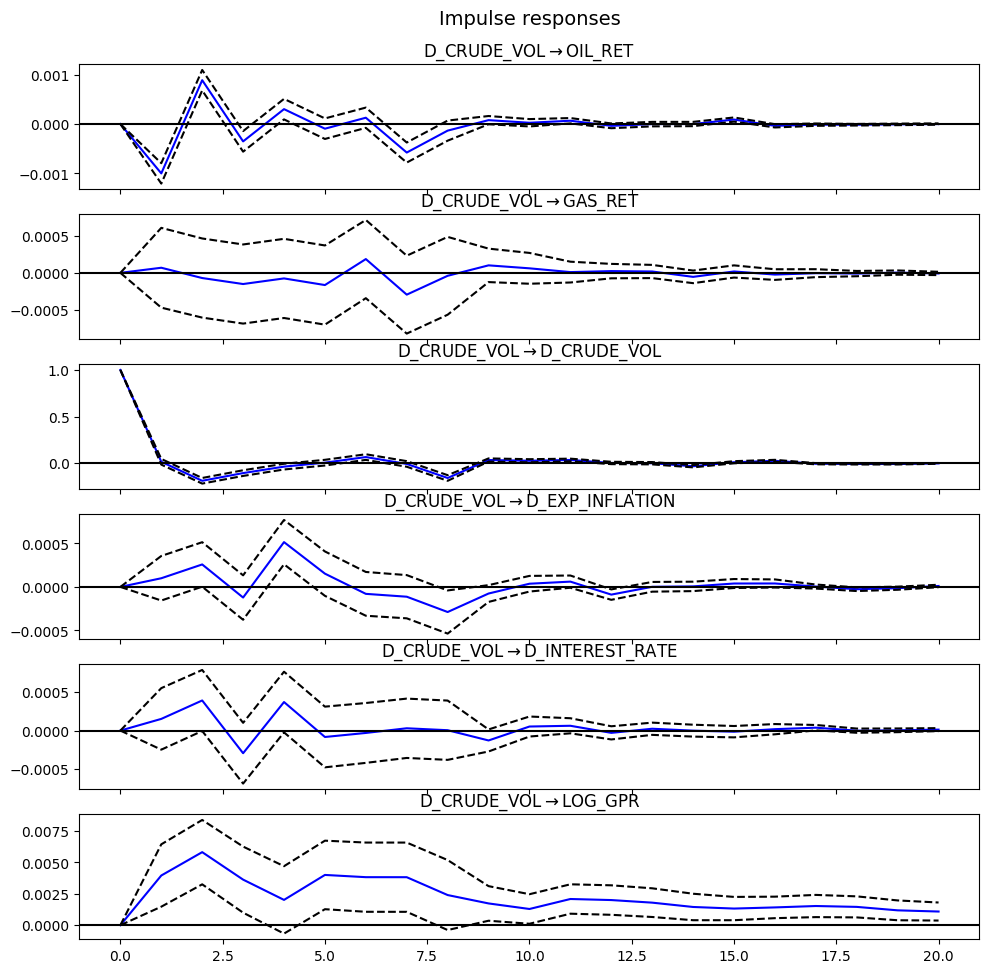

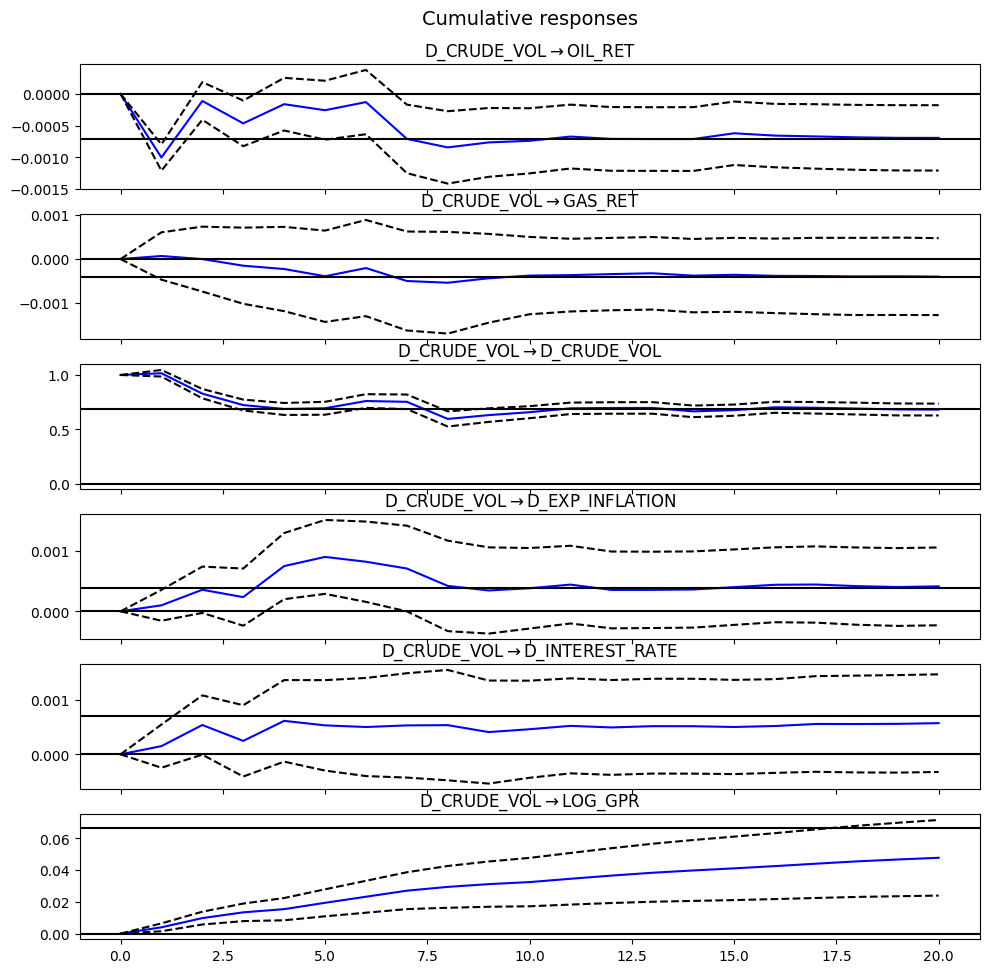

In [13]:
# Compute orthogonalized IRFs (default uses Cholesky ordering based on DataFrame column order)
irf = results.irf(periods=20)

# Plot responses to a GPR shock
fig = irf.plot(impulse='D_CRUDE_VOL')
plt.show()

# Cumulative IRF (to see net directional impact over time)
fig_cum = irf.plot_cum_effects(impulse='D_CRUDE_VOL')
plt.show()

In [14]:
def compute_girf_matrix(results, periods=10):
    # Ensure sigma_u is a raw numpy ndarray, not a pandas DataFrame
    sigma_u = np.asarray(results.sigma_u)  # <--- FIX HERE
    names = list(results.names)
    k = len(names)

    # MA coefficient matrices: (periods + 1, K, K)
    ma_rep = results.ma_rep(maxn=periods)

    girf_dict = {
        imp: {resp: np.zeros(periods + 1) for resp in names} for imp in names
    }

    for j, imp_var in enumerate(names):
        sigma_jj = sigma_u[j, j]  # Now standard numpy integer index lookup works
        scale = 1.0 / np.sqrt(sigma_jj)

        cov_vector = sigma_u[:, j]

        for h in range(periods + 1):
            phi_h = ma_rep[h]
            response_at_h = (phi_h @ cov_vector) * scale

            for i, resp_var in enumerate(names):
                girf_dict[imp_var][resp_var][h] = response_at_h[i]

    return girf_dict

In [15]:
periods = 10
girf_results = compute_girf_matrix(results, periods=periods)

# 2. Inspect a specific shock-response trajectory
# Example: Impact of a 1-SD shock to 'LOG_GPR' on 'OIL_PRICE' over 10 days
shock_var = "D_CRUDE_VOL"
target_var = "OIL_RET"

response_path = girf_results[shock_var][target_var]
print(f"GIRF Response of {target_var} to {shock_var} shock:")
print(np.round(response_path, 4))

GIRF Response of OIL_RET to D_CRUDE_VOL shock:
[-0.0098 -0.0037  0.0035 -0.0014  0.0008 -0.0003  0.0006 -0.0019 -0.0009
 -0.      0.0003]


In [16]:
fevd = results.fevd(10)
print(fevd.summary())
# fevd.plot()
# plt.show()

FEVD for OIL_RET
      OIL_RET   GAS_RET  D_CRUDE_VOL  D_EXP_INFLATION  D_INTEREST_RATE   LOG_GPR
0    1.000000  0.000000     0.000000         0.000000         0.000000  0.000000
1    0.974666  0.000258     0.018855         0.005973         0.000247  0.000001
2    0.959808  0.000595     0.032431         0.006770         0.000395  0.000001
3    0.957081  0.000687     0.034585         0.007094         0.000394  0.000159
4    0.954784  0.000847     0.036121         0.007439         0.000557  0.000252
5    0.953414  0.000932     0.036223         0.008055         0.001123  0.000253
6    0.952841  0.001024     0.036471         0.008053         0.001350  0.000260
7    0.944951  0.001015     0.042271         0.009338         0.002158  0.000267
8    0.944615  0.001013     0.042492         0.009437         0.002158  0.000286
9    0.944526  0.001014     0.042562         0.009430         0.002164  0.000303

FEVD for GAS_RET
      OIL_RET   GAS_RET  D_CRUDE_VOL  D_EXP_INFLATION  D_INTEREST_RATE   L

In [ ]:
def plot_var_residual_diagnostics(var_results, equation_name, lags=20, bins=70):
    """
    Plots a 4-panel residual diagnostic grid for a single equation in a fitted VAR model.
    """
    # 1. Extract 1D residual series for the target equation
    resid = var_results.resid[equation_name].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # --- Panel 1: Residuals Over Time ---
    axes[0, 0].plot(resid.index, resid.values, color="#1f77b4", lw=0.8, alpha=0.85)
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.9)
    axes[0, 0].set_title(f"Residuals Over Time: {equation_name} (Volatility Clustering)", fontweight="bold")
    axes[0, 0].set_ylabel("Residual")
    axes[0, 0].grid(True, alpha=0.3)

    # --- Panel 2: Density vs Theoretical Normal ---
    axes[0, 1].hist(resid, bins=bins, density=True, alpha=0.55, color="#2ca02c", edgecolor="none")
    mu, std = stats.norm.fit(resid)
    xmin, xmax = axes[0, 1].get_xlim()
    x_pdf = np.linspace(xmin, xmax, 500)
    kurt = stats.kurtosis(resid, fisher=False)  # Pearson kurtosis (normal = 3.0)
    skew = stats.skew(resid)

    axes[0, 1].plot(
        x_pdf, stats.norm.pdf(x_pdf, mu, std), "r--", lw=2,
        label=rf"Normal ($\mu={mu:.3f}, \sigma={std:.3f}$)"
    )
    axes[0, 1].set_title(f"Empirical vs. Normal (Kurtosis: {kurt:.1f}, Skew: {skew:.2f})", fontweight="bold")
    axes[0, 1].set_ylabel("Density")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # --- Panel 3: Q-Q Plot (Heavy Tails) ---
    sm.qqplot(resid, line="45", fit=True, ax=axes[1, 0], color="#1f77b4", alpha=0.5)
    axes[1, 0].set_title("Normal Q-Q Plot (Tail Extremity)", fontweight="bold")
    axes[1, 0].grid(True, alpha=0.3)

    # --- Panel 4: Autocorrelation Function (ACF) ---
    sm.graphics.tsa.plot_acf(resid, lags=lags, ax=axes[1, 1], alpha=0.05)
    axes[1, 1].set_title(f"Residual ACF (Up to {lags} Lags)", fontweight="bold")
    axes[1, 1].set_xlabel("Lag")
    axes[1, 1].set_ylabel("Autocorrelation")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Example Usage:
# plot_var_residual_diagnostics(results, 'OIL')
# plot_var_residual_diagnostics(results, 'GAS')

In [ ]:
var_df_clean.columns

In [ ]:
plot_var_residual_diagnostics(results, 'D_CRUDE_VOL')

In [ ]:
# Find the exact date of the worst drop
worst_date = var_df['GAS_RET'].idxmin()
print("Worst outlier date:", worst_date)
print("Outlier value:", var_df.loc[worst_date, 'GAS_RET'])

# Check the top 5 most extreme absolute swings
print("\nTop 5 absolute swings in GAS_RET:")
print(var_df['GAS_RET'].abs().nlargest(5))